IMDB Dataset Loaded Successfully
Training Samples : 25000
Testing Samples : 25000


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 85ms/step - accuracy: 0.7689 - loss: 0.4681 - val_accuracy: 0.8598 - val_loss: 0.3398
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - accuracy: 0.8881 - loss: 0.2882 - val_accuracy: 0.8524 - val_loss: 0.3364
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - accuracy: 0.9245 - loss: 0.2067 - val_accuracy: 0.8756 - val_loss: 0.3194
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - accuracy: 0.9419 - loss: 0.1618 - val_accuracy: 0.8542 - val_loss: 0.3515
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - accuracy: 0.9459 - loss: 0.1480 - val_accuracy: 0.8640 - val_loss: 0.3787


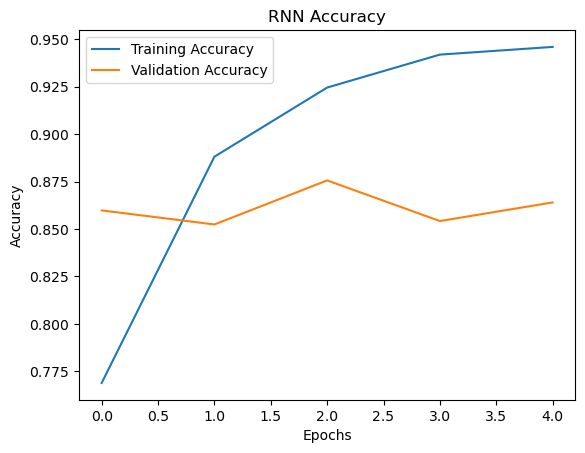

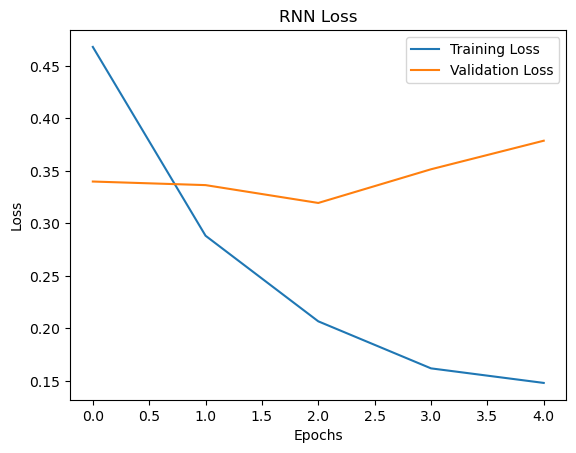

782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.8587 - loss: 0.3958

Test Accuracy : 0.858680009841919
Test Loss : 0.39578062295913696
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step

Review : This movie was very good and interesting
Sentiment : Positive 😊


In [2]:
# ---------------------------------------------------------
# SENTIMENT ANALYSIS USING RNN (LSTM)
# IMDB DATASET + VISUALIZATION
# ---------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import imdb


# ---------------------------------------------------------
# Step 1 : Load Dataset
# ---------------------------------------------------------

num_words = 10000
max_length = 256

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=num_words
)

print("IMDB Dataset Loaded Successfully")
print("Training Samples :", len(x_train))
print("Testing Samples :", len(x_test))


# Padding
x_train = pad_sequences(
    x_train,
    maxlen=max_length
)

x_test = pad_sequences(
    x_test,
    maxlen=max_length
)


# ---------------------------------------------------------
# Step 2 : Hyperparameters
# ---------------------------------------------------------

embedding_size = 64
rnn_units = 64
dropout_rate = 0.5
learning_rate = 0.001
epochs = 5
batch_size = 64


# ---------------------------------------------------------
# Step 3 : Build RNN Model
# ---------------------------------------------------------

model = Sequential()


# Embedding Layer
model.add(
    Embedding(
        input_dim=num_words,
        output_dim=embedding_size
    )
)


# RNN Layer (LSTM)
model.add(
    LSTM(
        rnn_units
    )
)


# Dropout
model.add(
    Dropout(
        dropout_rate
    )
)


# Dense Layer
model.add(
    Dense(
        32,
        activation='relu'
    )
)


# Output Layer
model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)


# ---------------------------------------------------------
# Step 4 : Compile Model
# ---------------------------------------------------------

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()


# ---------------------------------------------------------
# Step 5 : Train Model
# ---------------------------------------------------------

history = model.fit(
    x_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2
)


# ---------------------------------------------------------
# Step 6 : Accuracy Graph
# ---------------------------------------------------------

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("RNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


# ---------------------------------------------------------
# Step 7 : Loss Graph
# ---------------------------------------------------------

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("RNN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()


# ---------------------------------------------------------
# Step 8 : Evaluate Model
# ---------------------------------------------------------

loss, accuracy = model.evaluate(
    x_test,
    y_test
)

print("\nTest Accuracy :", accuracy)
print("Test Loss :", loss)


# ---------------------------------------------------------
# Step 9 : Prediction Example
# ---------------------------------------------------------

word_index = imdb.get_word_index()


def preprocess_text(text):

    words = text.lower().split()

    encoded = [
        word_index.get(word, 0)
        for word in words
    ]

    padded = pad_sequences(
        [encoded],
        maxlen=max_length
    )

    return padded


review = "This movie was very good and interesting"

processed_review = preprocess_text(
    review
)

prediction = model.predict(
    processed_review
)


print("\nReview :", review)

if prediction > 0.5:
    print("Sentiment : Positive 😊")
else:
    print("Sentiment : Negative 😞")